In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler
from jupyter_utils_multi import load_house_data
from jupyter_utils_general import dlc
np.set_printoptions(precision=2)
plt.style.use("./deeplearning.mplstyle")

In [2]:
x_train, y_train = load_house_data()
x_features = ["size (sqft)", "bedrooms", "floors", "age"]

In [3]:
scaler = StandardScaler()
x_norm = scaler.fit_transform(x_train)
print(f"Peak to Peak Range by Column in Raw X:{np.ptp(x_train, axis=0)}")
print(f"Peak to Peak Range by Column in Normalized X:{np.ptp(x_norm, axis=0)}")

Peak to Peak Range by Column in Raw X:[2.41e+03 4.00e+00 1.00e+00 9.50e+01]
Peak to Peak Range by Column in Normalized X:[5.85 6.14 2.06 3.69]


In [4]:
sgdr = SGDRegressor(max_iter=1000)
sgdr.fit(x_norm, y_train)
print(sgdr)
print(f"Number of Iterations Completed: {sgdr.n_iter_}, Number of Weight Updates: {sgdr.t_}")

SGDRegressor()
Number of Iterations Completed: 119, Number of Weight Updates: 11782.0


In [5]:
b_norm = sgdr.intercept_
w_norm = sgdr.coef_
print(f"model parameters: w: {w_norm}, b:{b_norm}")
print( "model parameters from previous lab: w: [110.56 -21.27 -32.71 -37.97], b: 363.16")

model parameters: w: [110.13 -21.01 -32.42 -38.05], b:[363.17]
model parameters from previous lab: w: [110.56 -21.27 -32.71 -37.97], b: 363.16


In [6]:
y_pred_sgd = sgdr.predict(x_norm)
y_pred = np.dot(x_norm, w_norm) + b_norm  
print(f"Prediction using np.dot() and sgdr.predict Match: {(y_pred == y_pred_sgd).all()}")

print(f"Prediction on Training Set:\n{y_pred[:4]}" )
print(f"Target Values \n{y_train[:4]}")

Prediction using np.dot() and sgdr.predict Match: True
Prediction on Training Set:
[295.18 485.98 389.68 492.15]
Target Values 
[300.  509.8 394.  540. ]


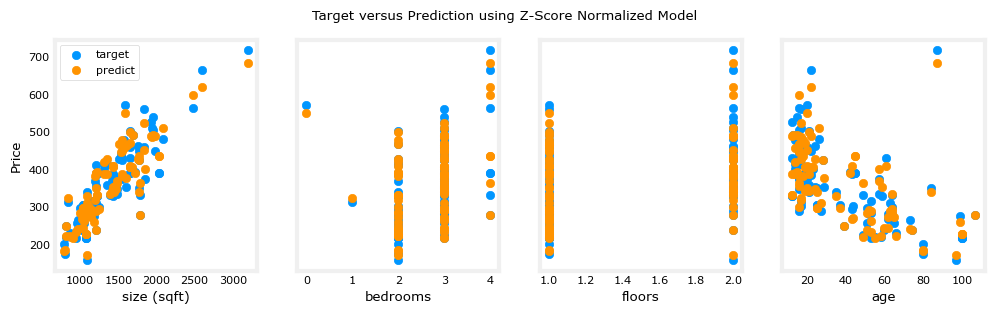

In [7]:
fig, ax = plt.subplots(1, 4, figsize=(12, 3), sharey=True)
for i in range(len(ax)):
    ax[i].scatter(x_train[:, i], y_train, label='target')
    ax[i].set_xlabel(x_features[i])
    ax[i].scatter(x_train[:, i], y_pred, color=dlc["dlorange"], label='predict')
ax[0].set_ylabel("Price")
ax[0].legend()
fig.suptitle("Target versus Prediction using Z-Score Normalized Model")
plt.show()